# Retail Sales Data Analysis

This notebook performs Exploratory Data Analysis (EDA) on retail sales data.

The analysis covers:
- Dataset inspection
- Descriptive statistics
- Monthly and quarterly sales trends
- Customer demographics
- Product performance
- Correlation analysis
- Additional business insights

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [4]:
df.shape

(120000, 17)

In [5]:
df.columns

Index(['transaction_id', 'transaction_date', 'customer_id', 'customer_gender',
       'customer_age_group', 'customer_segment', 'product_id', 'product_name',
       'category', 'brand', 'quantity', 'unit_price', 'discount_pct',
       'sales_amount', 'payment_method', 'sales_channel', 'region'],
      dtype='str')

In [6]:
df.dtypes

transaction_id            str
transaction_date          str
customer_id               str
customer_gender           str
customer_age_group        str
customer_segment          str
product_id                str
product_name              str
category                  str
brand                     str
quantity                int64
unit_price            float64
discount_pct            int64
sales_amount          float64
payment_method            str
sales_channel             str
region                    str
dtype: object

In [7]:
df.isnull().sum()

transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

In [8]:
df.isnull().mean() * 100

transaction_id        0.0
transaction_date      0.0
customer_id           0.0
customer_gender       0.0
customer_age_group    0.0
customer_segment      0.0
product_id            0.0
product_name          0.0
category              0.0
brand                 0.0
quantity              0.0
unit_price            0.0
discount_pct          0.0
sales_amount          0.0
payment_method        0.0
sales_channel         0.0
region                0.0
dtype: float64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  str    
 1   transaction_date    120000 non-null  str    
 2   customer_id         120000 non-null  str    
 3   customer_gender     120000 non-null  str    
 4   customer_age_group  120000 non-null  str    
 5   customer_segment    120000 non-null  str    
 6   product_id          120000 non-null  str    
 7   product_name        120000 non-null  str    
 8   category            120000 non-null  str    
 9   brand               120000 non-null  str    
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  int64  
 13  sales_amount        120000 non-null  float64
 14  payment_method      120000 non-null  str    
 15  sales_channel       120000 non-null  str    


## 1. Initial Dataset Inspection
### Observation
The dataset was loaded and inspected to understand its basic structure.

The dataset contains 120,000 rows and 17 columns. The columns contain
information about transactions, customers, products, sales amounts,
payment methods, sales channels, and regions.

The data types of the columns were checked to identify numerical,
categorical, and date-related variables. Missing values were also
checked to ensure that the dataset was suitable for further analysis.

The transaction_date column was converted from an object type to a
datetime type so that time-based analysis could be performed.

In [32]:
numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    print("\n", column)
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Mode:", df[column].mode()[0])
    print("Standard Deviation:", df[column].std())


 quantity
Mean: 1.6629083333333334
Median: 1.0
Mode: 1
Standard Deviation: 1.0142909418972674

 unit_price
Mean: 240.62178483333335
Median: 238.75
Mode: 95.79
Standard Deviation: 146.45705742883004

 discount_pct
Mean: 5.4965
Median: 0.0
Mode: 0
Standard Deviation: 8.19325721730163

 sales_amount
Mean: 377.97545375
Median: 295.98
Mode: 128.4
Standard Deviation: 356.89335696303056


## 2. Descriptive Statistics
### Observation
Descriptive statistics were calculated for all numerical columns in
the dataset.

The mean represents the average value, while the median represents
the middle value of the data. The mode represents the most frequently
occurring value, and standard deviation shows how much the values
vary from the average.

The analysis helps us understand the typical quantity sold, product
prices, discount percentages, and sales amounts.

The difference between the mean and median of sales amount also
suggests that some higher-value transactions may be affecting the
average sales value.

In [15]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["transaction_date"].dtype

dtype('<M8[us]')

In [16]:
monthly_sales = df.groupby(df["transaction_date"].dt.to_period("M"))["sales_amount"].sum()
monthly_sales

transaction_date
2024-01    1980147.17
2024-02    1797169.80
2024-03    1885630.00
2024-04    1862123.73
2024-05    1946801.10
2024-06    1892102.05
2024-07    1907030.93
2024-08    1947600.00
2024-09    1858013.87
2024-10    1833992.24
2024-11    1955443.63
2024-12    1920349.49
2025-01    1925284.04
2025-02    1793455.91
2025-03    1813051.32
2025-04    1862967.35
2025-05    1921171.94
2025-06    1838634.83
2025-07    2007036.02
2025-08    1967685.22
2025-09    1836361.30
2025-10    1949976.97
2025-11    1783231.12
2025-12    1871794.42
Freq: M, Name: sales_amount, dtype: float64

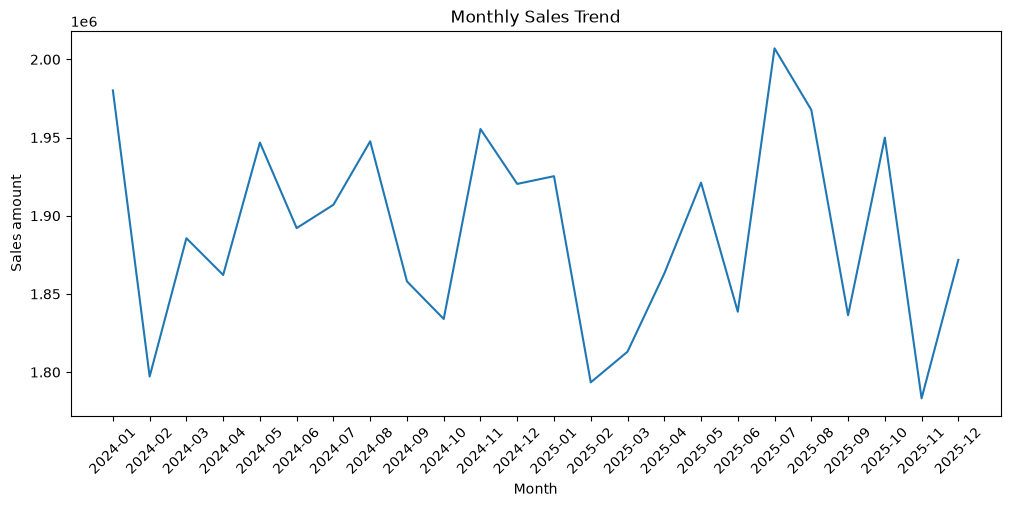

In [17]:
plt.figure(figsize = (12,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales amount")

plt.xticks(rotation=45)

plt.show()

## 3. Monthly Sales Trend
### Observation
A monthly sales trend was created by grouping transactions according
to their transaction month and calculating the total sales amount.

The line chart shows how sales changed from month to month. Some
months have higher sales while others have lower sales, indicating
variation in customer purchasing activity over time.

Monthly sales trends can help businesses identify periods of high
demand and plan inventory, marketing campaigns, and staffing
accordingly.

In [18]:
quarterly_sales = df.groupby(
    df["transaction_date"].dt.to_period("Q")
)["sales_amount"].sum()
quarterly_sales

transaction_date
2024Q1    5662946.97
2024Q2    5701026.88
2024Q3    5712644.80
2024Q4    5709785.36
2025Q1    5531791.27
2025Q2    5622774.12
2025Q3    5811082.54
2025Q4    5605002.51
Freq: Q-DEC, Name: sales_amount, dtype: float64

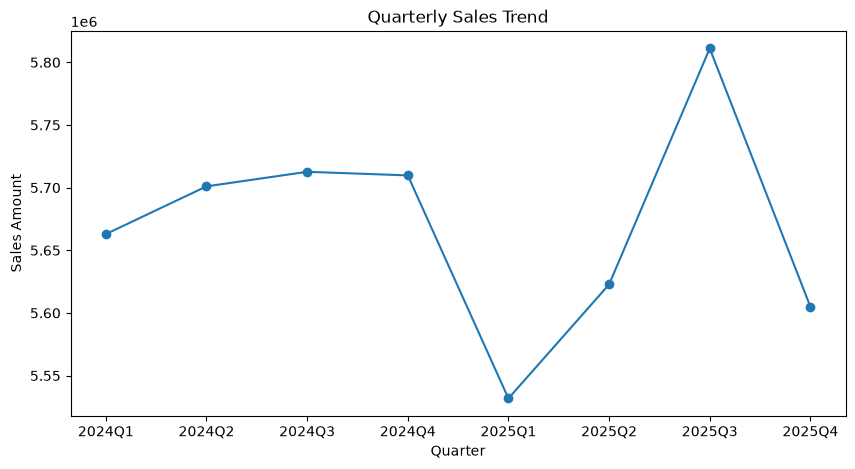

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker = "o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales Amount")

plt.show()


## 4. Quarterly Sales Trend
### Observation
The sales data was also grouped into quarters to identify broader
sales trends.

The quarterly line chart provides a larger view of business
performance compared with the monthly analysis. It helps identify
whether sales are generally increasing, decreasing, or remaining
stable across longer periods.

Quarterly analysis can be useful for business planning and comparing
performance between different periods of the year.

In [20]:
age_groups = df["customer_age_group"].value_counts()
age_groups

customer_age_group
35-44    24196
55+      24078
18-24    23941
45-54    23919
25-34    23866
Name: count, dtype: int64

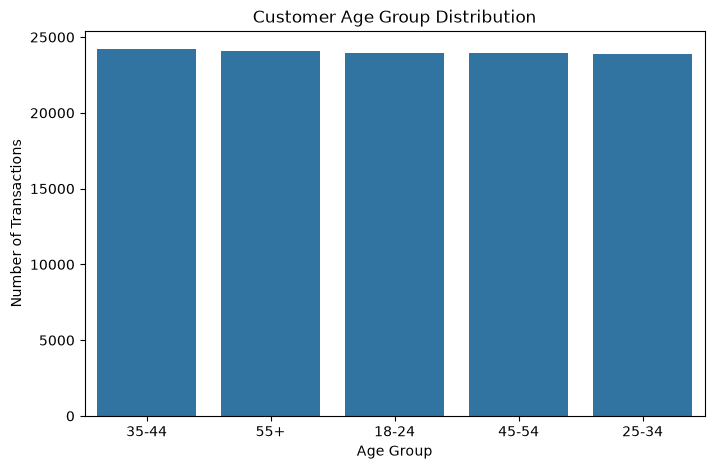

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_groups.index,
    y=age_groups.values
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

plt.show()

## 5. Customer Age Group Distribution
### Observation
The distribution of customer age groups was analyzed to understand
which age groups contribute most to the transactions.

The chart shows the number of transactions associated with each
customer age group. The distribution provides an overview of the
customer base and helps identify the major age groups purchasing
products.

This information can be useful when developing targeted marketing
campaigns for different customer groups.

In [22]:
gender_counts = df["customer_gender"].value_counts()
gender_counts

customer_gender
Female    40268
Other     39906
Male      39826
Name: count, dtype: int64

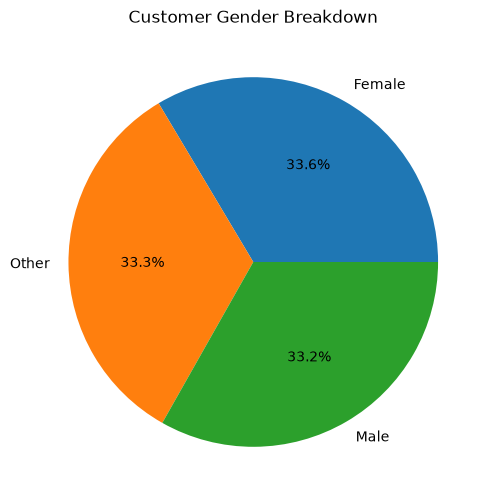

In [23]:
plt.figure(figsize=(6, 6))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Customer Gender Breakdown")

plt.show()

## 6. Customer Gender Breakdown
### Observation
The gender distribution of customers was analyzed to understand the
proportion of transactions associated with each gender category.

The results show that the customer distribution is relatively balanced
across the available gender categories.

This suggests that the dataset does not show a strong concentration
of transactions toward a single gender group.

In [24]:
top_products = df.groupby("product_name")["quantity"].sum()

top_products = top_products.sort_values(ascending=False).head(10)

top_products

product_name
Dumbbells          5212
Lamp               5156
Puzzle             5140
Jeans              5123
Jacket             5116
Cereal             5113
T-Shirt            5099
Shampoo            5089
Building Blocks    5087
Milk               5080
Name: quantity, dtype: int64

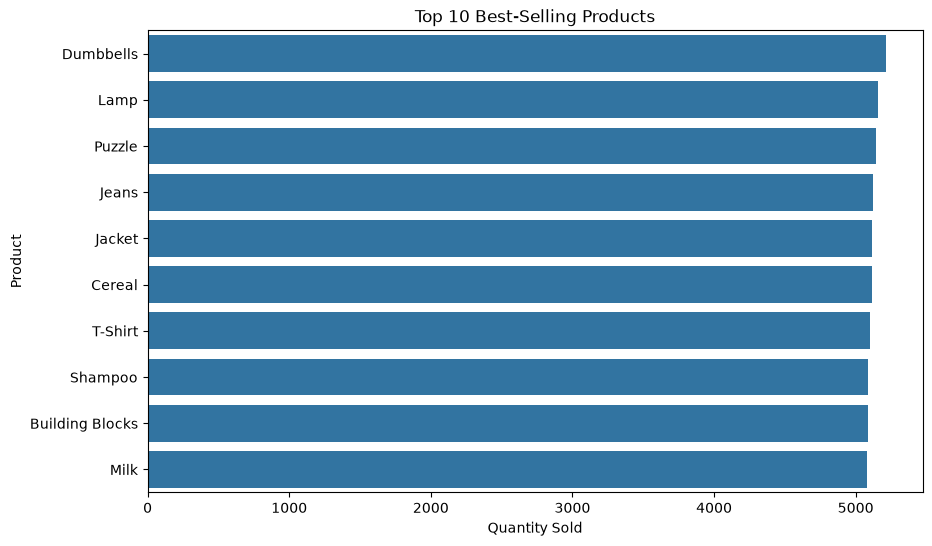

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

## 7. Top 10 Best-Selling Products
### Observation
The top 10 best-selling products were identified by calculating the
total quantity sold for each product.

The bar chart shows which products have the highest sales volume.
Products appearing at the top of the list have stronger customer
demand compared with other products.

These products should be monitored carefully to maintain sufficient
inventory and avoid stock shortages. The business can also consider
promoting related products to customers purchasing these popular
items.

In [26]:
category_sales = df.groupby("category")["sales_amount"].sum()

category_sales = category_sales.sort_values(ascending=False)

category_sales

category
Beauty         6355718.23
Books          6005237.69
Sports         5863370.76
Electronics    5859686.69
Home           5655562.80
Toys           5557562.19
Groceries      5431536.64
Clothing       4628379.45
Name: sales_amount, dtype: float64

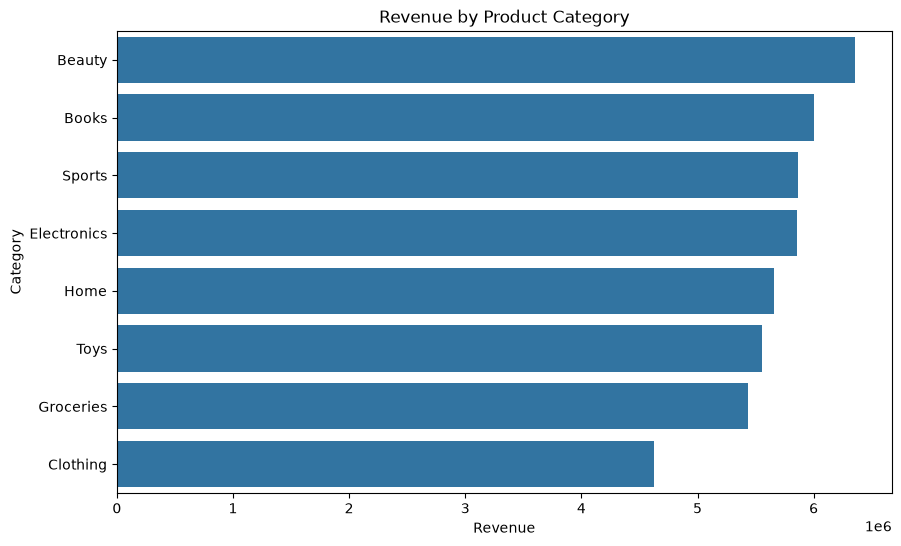

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()

## 8. Revenue by Product Category
### Observation
Total revenue was calculated for each product category.

The bar chart allows us to compare the financial contribution of
different product categories. The analysis shows which categories
generate the highest and lowest revenue.

High-performing categories should be monitored to maintain their
strong performance, while lower-performing categories can be studied
to identify opportunities for improvement through pricing,
promotions, or marketing.

In [28]:
correlation = df.select_dtypes(include="number").corr()

correlation

,quantity,unit_price,discount_pct,sales_amount
quantity,1.000000,-0.001101,0.001618,0.644725
unit_price,-0.001101,1.000000,-0.000484,0.643164
discount_pct,0.001618,-0.000484,1.000000,-0.091330
sales_amount,0.644725,0.643164,-0.091330,1.000000


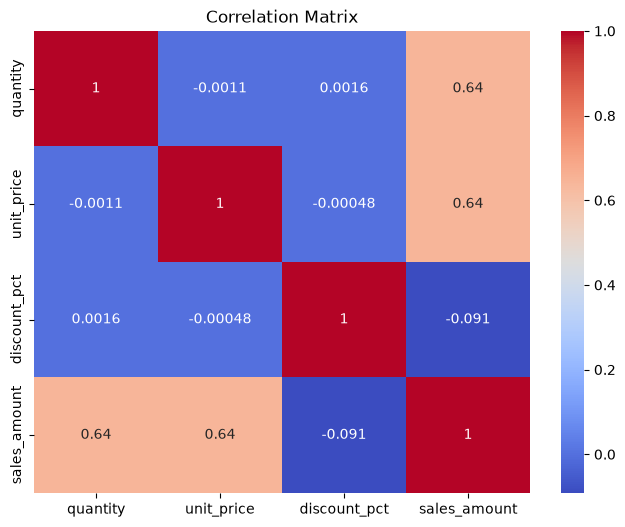

In [29]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## 9. Correlation Analysis
### Observation
A correlation matrix was created to study the relationships between
the numerical variables in the dataset.

The heatmap makes it easier to identify positive and negative
relationships between variables.

For example, sales amount has a positive relationship with variables
such as quantity and unit price. This indicates that transactions
with higher quantities or higher-priced products generally tend to
have higher sales amounts.

Correlation shows the strength of a relationship between variables,
but it does not necessarily mean that one variable causes another.

In [30]:
channel_sales = df.groupby("sales_channel")["sales_amount"].mean()

channel_sales

sales_channel
In-Store      381.363486
Mobile App    374.738419
Online        377.835932
Name: sales_amount, dtype: float64

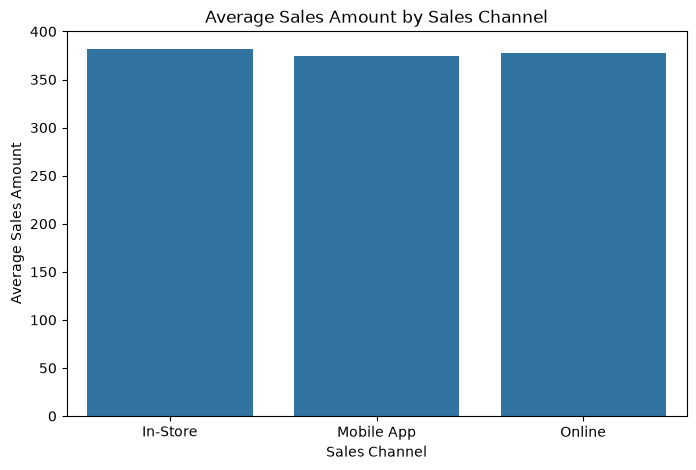

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=channel_sales.index,
    y=channel_sales.values
)

plt.title("Average Sales Amount by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Average Sales Amount")

plt.show()

## 10. Additional Analysis: Sales Channel
### Observation
An additional visualization was created to compare the average sales
amount across different sales channels.

The analysis compares channels such as Online, Mobile App, and
In-Store to determine whether customers spend different amounts per
transaction depending on the channel they use.

The results show that the average transaction value is relatively
similar across the different sales channels, with only small
differences between them.

This suggests that customer spending per transaction is fairly
consistent across channels. However, the business should also examine
the number of transactions and total revenue from each channel before
making decisions about channel performance.

# Conclusion and Business Recommendations

The exploratory data analysis revealed useful patterns in sales,
customer behaviour, and product performance.

### 1. Maintain sufficient stock of best-selling products

The top 10 best-selling products have higher sales quantities than
other products. The business should maintain sufficient inventory
levels for these products and monitor their stock regularly to reduce
the risk of stockouts.

### 2. Focus marketing efforts on high-revenue categories

The revenue analysis shows that some product categories generate more
revenue than others. The business should prioritize marketing and
promotional campaigns for high-performing categories while improving
the visibility of lower-performing categories.

### 3. Use sales trends for inventory and promotion planning

The monthly and quarterly sales analysis shows changes in sales over
time. The business should use these trends to increase inventory and
run promotional campaigns during periods of higher demand.

### 4. Develop targeted customer marketing

The customer demographic analysis shows the distribution of customers
across different age groups and genders. The business can use this
information to create targeted offers and marketing campaigns for
customer groups with higher transaction activity.

### 5. Continue supporting multiple sales channels

The analysis of sales channels shows that average transaction values
are relatively similar across Online, Mobile App, and In-Store
channels. The business should continue supporting all channels while
monitoring their transaction volume and total revenue to identify
opportunities for improvement.